# IBM HR Attrition Prediction
 
**Goal:** Predict whether an employee is likely to leave the company using HR data.
 
**Why it matters:** Employee attrition is expensive. Recruiting and onboarding a replacement can cost months of salary. A model that identifies at-risk employees early gives HR teams a chance to act before it's too late.
 
**Target variable:** `Attrition`  Yes (left) or No (stayed)
 
**Challenge:** The dataset is heavily imbalanced with only 16% attrition, meaning accuracy alone is a misleading metric. This project prioritizes **recall** on the minority class.
 
**Approach:**
- XGBoost classifier with `scale_pos_weight` to handle class imbalance
- GridSearchCV for hyperparameter tuning
- Threshold tuning to maximize employees caught

&nbsp;

| Step | Details |
|---|---|
| Dataset | IBM HR Analytics, 1,470 rows, 35 features |
| Model | XGBoost |
| Imbalance handling | scale_pos_weight = 5.19 |
| Final threshold | 0.30 |
| Employees caught | 40 / 47 in test set |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
df = pd.read_csv('../data/Employee-attrition.csv')

In [3]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

MonthlyIncome: 114 outliers
NumCompaniesWorked: 52 outliers
PerformanceRating: 226 outliers
StockOptionLevel: 85 outliers
TotalWorkingYears: 63 outliers
TrainingTimesLastYear: 238 outliers
YearsAtCompany: 104 outliers
YearsInCurrentRole: 21 outliers
YearsSinceLastPromotion: 107 outliers
YearsWithCurrManager: 14 outliers


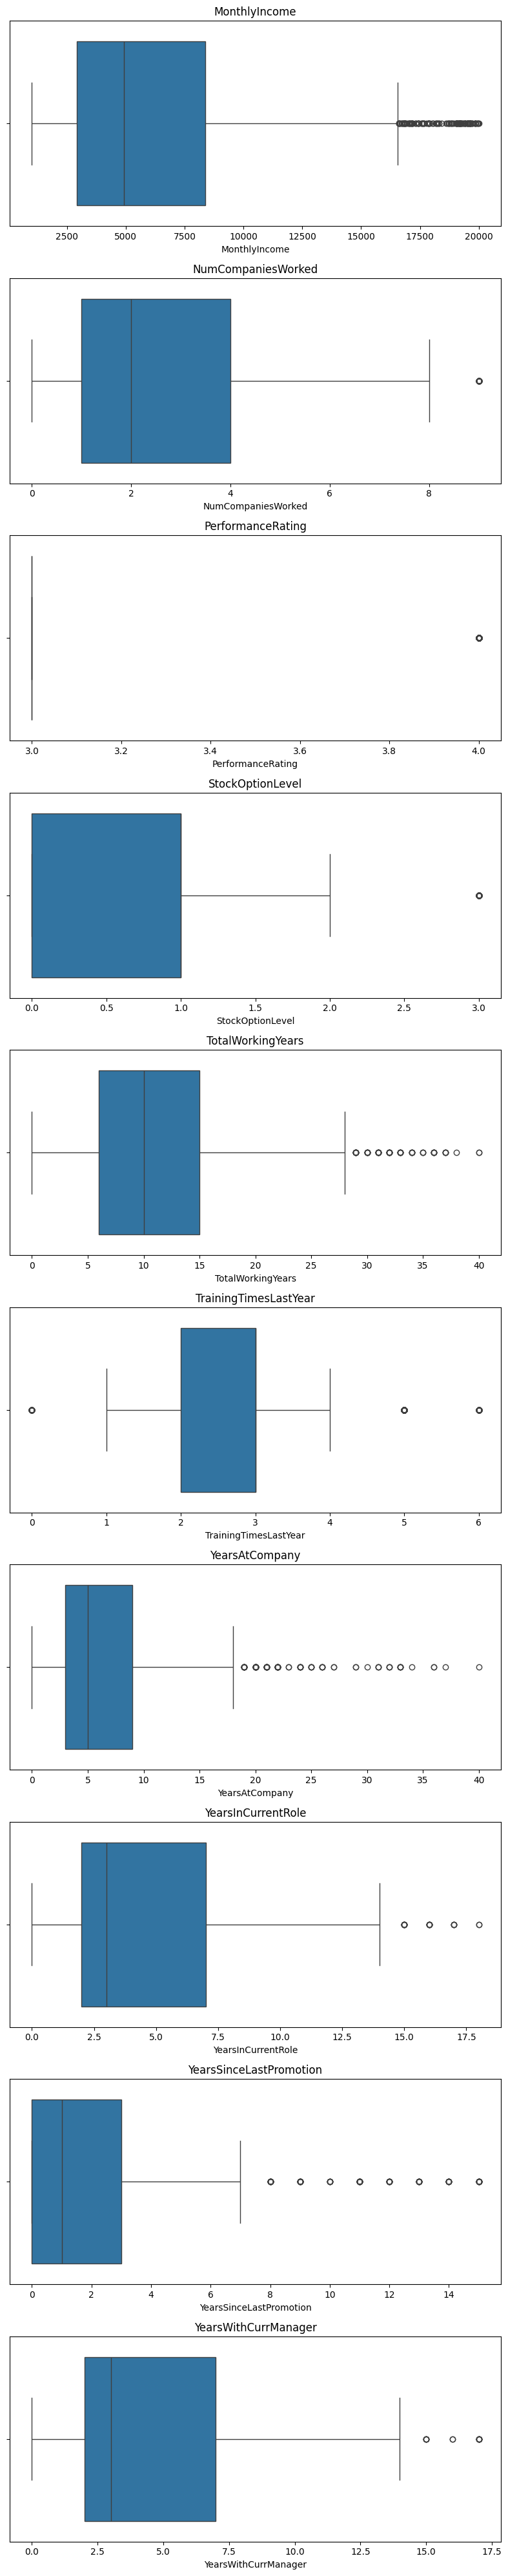

In [8]:
# Step 1: Find all numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Step 2: Identify only columns WITH outliers
cols_with_outliers = []
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    if len(outliers) > 0:
        cols_with_outliers.append(col)
        print(f"{col}: {len(outliers)} outliers")

# Step 3: Plot ONLY those columns
fig, axes = plt.subplots(len(cols_with_outliers), 1, figsize=(8, 4*len(cols_with_outliers)))

for i, col in enumerate(cols_with_outliers):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [9]:
# Returns the count of unique values for all columns
unique_counts = df.nunique()
print(unique_counts)

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

In [10]:
# Dropping the columns, EmployeeCount, StandardHours, and Over18 because they have constant columns (same value for all 1470 rows).
df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18'], inplace=True)

In [11]:
# Returns the count of unique values for all object columns
obj_cols = df.select_dtypes(include='object').columns
print(df[obj_cols].nunique())

Attrition         2
BusinessTravel    3
Department        3
EducationField    6
Gender            2
JobRole           9
MaritalStatus     3
OverTime          2
dtype: int64


In [12]:
#checking the unique values in object columns
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}\n")

Attrition: ['Yes' 'No']

BusinessTravel: ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

Department: ['Sales' 'Research & Development' 'Human Resources']

EducationField: ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']

Gender: ['Female' 'Male']

JobRole: ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']

MaritalStatus: ['Single' 'Married' 'Divorced']

OverTime: ['Yes' 'No']



In [13]:
cols_map = {
    # Attrition & Overtime
    'No': 0, 'Yes': 1,
    # BusinessTravel
    'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2,
    # Gender
    'Female': 0, 'Male': 1,
    # MaritalStatus
    'Married': 0, 'Divorced': 1, 'Single': 2,
    # Department
    'Human Resources': 0, 'Research & Development': 1, 'Sales': 2,
}

df['Attrition']      = df['Attrition'].map(cols_map)
df['BusinessTravel'] = df['BusinessTravel'].map(cols_map)
df['Gender']         = df['Gender'].map(cols_map)
df['MaritalStatus']  = df['MaritalStatus'].map(cols_map)
df['Department']     = df['Department'].map(cols_map)
df['OverTime']       = df['OverTime'].map(cols_map)

In [14]:
df.dtypes

Age                          int64
Attrition                    int64
BusinessTravel               int64
DailyRate                    int64
Department                   int64
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                       int64
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus                int64
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
OverTime                     int64
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StockOptionLevel             int64
TotalWorkingYears            int64
TrainingTimesLastYear        int64
WorkLifeBalance              int64
YearsAtCompany      

In [15]:
df.drop(columns=['EmployeeNumber'], inplace=True)

In [16]:
# Feature engineering
# Making new columns
# Employees with low satisfaction across multiple areas are more at risk than those low in just one
df['AvgSatisfaction'] = df[['EnvironmentSatisfaction', 'JobSatisfaction', 
                              'RelationshipSatisfaction', 'WorkLifeBalance']].mean(axis=1)

# Catches underpaid employees - someone with many years of experience earning low salary feels undervalued
df['IncomePerYearExp'] = df['MonthlyIncome'] / (df['TotalWorkingYears'] + 1)

# Measures how "stuck" an employee feels - long time without promotion despite years at company is a red flag
df['StagnationRatio'] = df['YearsSinceLastPromotion'] / (df['YearsAtCompany'] + 1)

# Employees past 5 years have already passed the most common quitting window, marking them as low risk
df['IsLoyal'] = (df['YearsAtCompany'] > 5).astype(int)

# Overtime alone doesn't always cause attrition, but overtime + poor work life balance is a dangerous combo
df['IsOverworked'] = ((df['OverTime'] == 1) & (df['WorkLifeBalance'] <= 2)).astype(int)

# Measures career progression speed - slow growth after many years often leads to frustration and leaving
df['CareerGrowthRate'] = df['JobLevel'] / (df['TotalWorkingYears'] + 1)

In [17]:
df['Attrition'].value_counts(normalize=True)

Attrition
0    0.838776
1    0.161224
Name: proportion, dtype: float64

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

#Define x and y
x = df.drop('Attrition',axis=1)
y = df['Attrition']

x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,
                                                    random_state=42, 
                                                    stratify=y  # This ensures both sets have 16% attrition
)


#changing the objects into float values using one hot encoder
features_cat = ['EducationField','JobRole']
changed = ColumnTransformer([('worker_name',OneHotEncoder(handle_unknown='ignore'),features_cat)],
                            remainder = 'passthrough')

x_train = changed.fit_transform(x_train)  # fit + transform on train
x_test = changed.transform(x_test)        # only transform on test, no fitting
pd.DataFrame(x_test)

,0,1,2,3,4,5,6,7,8,9,...,39,40,41,42,43,44,45,46,47,48
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,3.00,1016.500000,0.000000,0.0,0.0,0.500000
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,5.0,7.0,7.0,3.00,182.818182,0.636364,1.0,0.0,0.090909
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,5.0,4.0,0.0,1.0,3.00,1050.636364,0.000000,0.0,0.0,0.272727
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,25.0,9.0,14.0,13.0,2.50,710.740741,0.538462,1.0,0.0,0.185185
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,2.50,1129.333333,0.000000,0.0,1.0,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,9.0,7.0,1.0,8.0,2.75,321.727273,0.100000,1.0,0.0,0.090909
290,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,0.0,2.0,2.0,2.50,457.545455,0.666667,0.0,0.0,0.181818
291,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,2.0,2.0,2.0,2.00,360.823529,0.666667,0.0,0.0,0.117647
292,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,2.0,1.0,0.0,2.50,344.333333,0.250000,0.0,0.0,0.166667


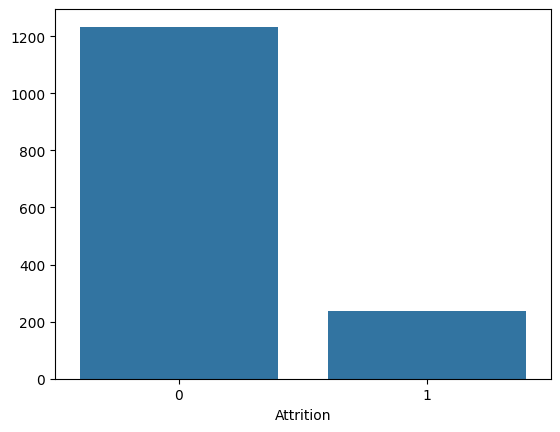

In [19]:
sns.barplot(x=df['Attrition'].value_counts().index, y=df['Attrition'].value_counts().values)
plt.show()

In [20]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

rfc = RandomForestClassifier(random_state=42)
xgbc = XGBClassifier(random_state=42)

rfc.fit(x_train,y_train)
xgbc.fit(x_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [21]:
print('rfc train score=',rfc.score(x_train, y_train))
print('xgbc train score=',xgbc.score(x_train, y_train))

rfc train score= 1.0
xgbc train score= 1.0


In [22]:
print('rfc test score=',rfc.score(x_test,y_test))
print('xgbc test score=',xgbc.score(x_test,y_test))

rfc test score= 0.8333333333333334
xgbc test score= 0.8435374149659864


In [23]:
from sklearn.metrics import classification_report

rfc_pred = rfc.predict(x_test)
xgbc_pred = xgbc.predict(x_test)

print("Random Forest:")
print(classification_report(y_test, rfc_pred))

print("XGBoost:")
print(classification_report(y_test, xgbc_pred))

Random Forest:
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.42      0.11      0.17        47

    accuracy                           0.83       294
   macro avg       0.63      0.54      0.54       294
weighted avg       0.78      0.83      0.79       294

XGBoost:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91       247
           1       0.53      0.21      0.30        47

    accuracy                           0.84       294
   macro avg       0.70      0.59      0.61       294
weighted avg       0.81      0.84      0.81       294



In [24]:
# ratio of majority to minority class
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f"scale_pos_weight = {scale:.2f}")  # should be around 5-6

xgbc_balanced = XGBClassifier(random_state=42, scale_pos_weight=scale)
xgbc_balanced.fit(x_train, y_train)

xgbc_bal_pred = xgbc_balanced.predict(x_test)
print(classification_report(y_test, xgbc_bal_pred))

scale_pos_weight = 5.19
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       247
           1       0.63      0.36      0.46        47

    accuracy                           0.86       294
   macro avg       0.76      0.66      0.69       294
weighted avg       0.85      0.86      0.85       294



In [25]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(xgbc_balanced, x_train, y_train, 
                         cv=cv, 
                         scoring='f1')  # f1 for class 1, not accuracy

print(f"F1 scores per fold: {scores.round(3)}")
print(f"Mean F1: {scores.mean():.3f}")
print(f"Std: {scores.std():.3f}")

F1 scores per fold: [0.508 0.475 0.484 0.467 0.453]
Mean F1: 0.477
Std: 0.018


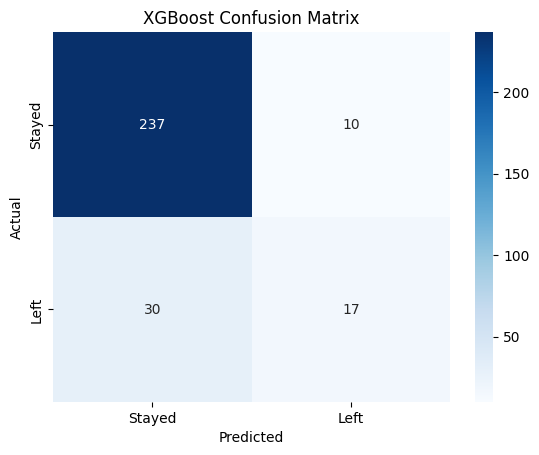

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, xgbc_bal_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'],
            yticklabels=['Stayed', 'Left'])

plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],          # lower = less overfit
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],    # rows per tree
    'colsample_bytree': [0.7, 0.8, 1.0], # features per tree
    'min_child_weight': [1, 3, 5]    # higher = more conservative
}

grid_search = GridSearchCV(
    XGBClassifier(random_state=42, scale_pos_weight=5.19),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='recall',  # optimizing for catching more leavers
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Recall Score:", grid_search.best_score_)

Fitting 5 folds for each of 729 candidates, totalling 3645 fits
Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 100, 'subsample': 0.8}
Best Recall Score: 0.6157894736842106


In [28]:
# Evaluate best model
best_model = grid_search.best_estimator_
best_pred = best_model.predict(x_test)
print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.91      0.84      0.88       247
           1       0.41      0.57      0.48        47

    accuracy                           0.80       294
   macro avg       0.66      0.71      0.68       294
weighted avg       0.83      0.80      0.81       294



In [29]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# Get probabilities instead of hard predictions
y_probs = best_model.predict_proba(x_test)[:, 1]

# Check different thresholds
thresholds = np.arange(0.1, 0.6, 0.05)

print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'Caught/47'}")
print("-" * 55)

for thresh in thresholds:
    y_pred_thresh = (y_probs >= thresh).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score
    p = precision_score(y_test, y_pred_thresh)
    r = recall_score(y_test, y_pred_thresh)
    f = f1_score(y_test, y_pred_thresh)
    caught = (y_pred_thresh & y_test).sum()
    print(f"{thresh:<12.2f} {p:<12.3f} {r:<12.3f} {f:<12.3f} {caught}/47")

Threshold    Precision    Recall       F1           Caught/47
-------------------------------------------------------
0.10         0.166        0.979        0.284        46/47
0.15         0.177        0.936        0.298        44/47
0.20         0.202        0.894        0.329        42/47
0.25         0.238        0.851        0.372        40/47
0.30         0.280        0.851        0.421        40/47
0.35         0.308        0.766        0.439        36/47
0.40         0.323        0.681        0.438        32/47
0.45         0.362        0.617        0.457        29/47
0.50         0.409        0.574        0.478        27/47
0.55         0.434        0.489        0.460        23/47


In [30]:
# Apply final threshold
final_threshold = 0.30
y_final_pred = (y_probs >= final_threshold).astype(int)

print(classification_report(y_test, y_final_pred))

              precision    recall  f1-score   support

           0       0.95      0.58      0.72       247
           1       0.28      0.85      0.42        47

    accuracy                           0.63       294
   macro avg       0.62      0.72      0.57       294
weighted avg       0.85      0.63      0.68       294



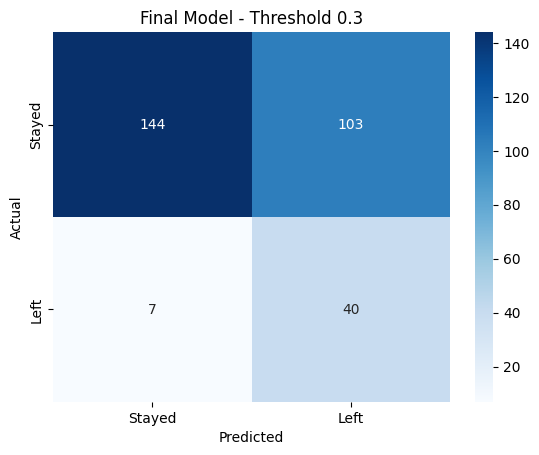

In [31]:
# Final confusion matrix
cm = confusion_matrix(y_test, y_final_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'],
            yticklabels=['Stayed', 'Left'])
plt.title(f'Final Model - Threshold {final_threshold}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

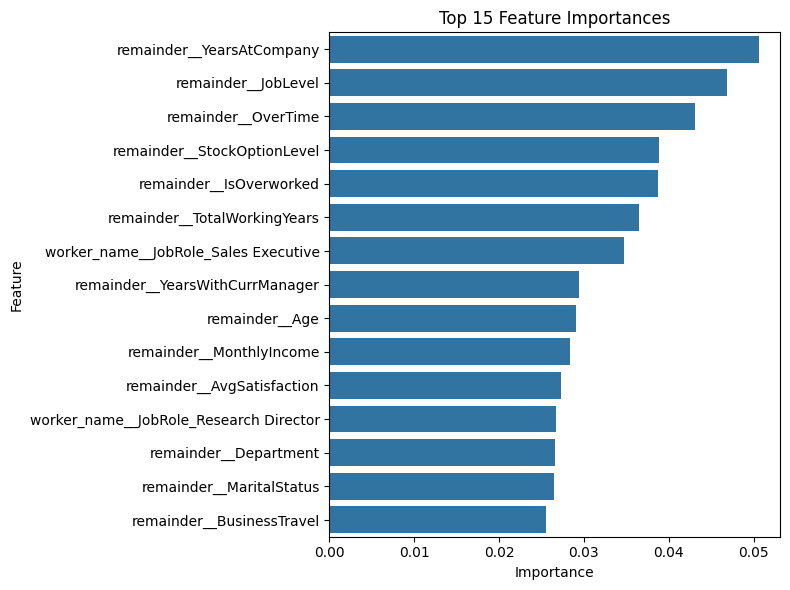

In [32]:
feature_names = changed.get_feature_names_out()
importances = best_model.feature_importances_

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

In [33]:
import joblib

joblib.dump(best_model, '../models/xgboost_ibm_attrition.pkl')
joblib.dump(changed, '../models/ohe_encoder.pkl')
joblib.dump(0.30, '../models/threshold.pkl')
joblib.dump(list(x.columns), '../models/attrition_columns.pkl')

['../models/attrition_columns.pkl']

## Summary
 
This project built an attrition prediction model using the IBM HR Analytics dataset. The pipeline covered data cleaning, outlier analysis, feature engineering, encoding, class imbalance handling, cross validation, hyperparameter tuning, and threshold tuning.
 
### Final Model Performance (Threshold = 0.30)
 
| Metric | Class 0 (Stayed) | Class 1 (Left) |
|---|---|---|
| Precision | 0.95 | 0.28 |
| Recall | 0.58 | 0.85 |
| F1 Score | 0.72 | 0.42 |
 
**Employees correctly flagged as at-risk: 40 out of 47**
 
### Key Findings
 
- `YearsAtCompany`, `JobLevel`, and `OverTime` were the strongest attrition signals
- The engineered feature `IsOverworked` ranked in the top 5, validating the feature engineering step
- Lowering the threshold from 0.50 to 0.30 improved minority class recall from 0.57 to 0.85
- The highest-risk employee profile: **junior level, working overtime, low stock options, fewer than 5 years at the company**
### Saved Artifacts
 
| File | Description |
|---|---|
| `models/xgboost_ibm_attrition.pkl` | Trained XGBoost model |
| `models/ohe_encoder.pkl` | ColumnTransformer with OneHotEncoder |
| `models/threshold.pkl` | Decision threshold (0.30) |